# Full Structural Multi-Model Analysis (Baseline-Centric)

This notebook aggregates **all `analysis_out/rome_structural_*.json` runs** and provides presentation-ready analysis across models and runs.

Design principles:
- Uses **baseline and absolute scores** (no delta plots).
- Shows **all runs per model** and variability across runs.
- Includes failed/incomplete runs in diagnostics.
- Focuses on model-level, run-level, and layer-level interpretability.


In [ ]:
import json, re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)

ROOT = Path.cwd()
if not (ROOT / 'analysis_out').exists():
    for p in ROOT.parents:
        if (p / 'analysis_out').exists():
            ROOT = p
            break

print('Repo root:', ROOT)

Repo root: /data/olexa/Latium


In [ ]:
def normalize_model_name(name: str) -> str:
    if not name:
        return 'unknown'
    n = str(name).strip()
    n_low = n.lower()
    aliases = {
        'qwen/qwen3-4b': 'qwen3-4b',
        'qwen-qwen3-4b': 'qwen3-4b',
        'qwen/qwen3-8b': 'qwen3-8b',
        'qwen-qwen3-8b': 'qwen3-8b',
        'mistralai/mistral-7b-v0.1': 'mistral-7b-v0.1',
        'mistralai/mistral-7b-v0.3': 'mistral-7b-v0.3',
    }
    return aliases.get(n_low, n)


def parse_run_timestamp(path_name: str):
    m = re.search(r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})\.json$', path_name)
    if not m:
        return pd.NaT
    return pd.to_datetime(m.group(1), format='%Y-%m-%d_%H-%M-%S', errors='coerce')


def get_layer_value(d, layer):
    if not isinstance(d, dict):
        return np.nan
    if layer in d:
        return d[layer]
    if str(layer) in d:
        return d[str(layer)]
    return np.nan


def get_tests(payload):
    if not isinstance(payload, dict):
        return []
    for key in ('tests', 'test_cases', 'runs'):
        tests = payload.get(key, [])
        if isinstance(tests, list):
            return [t for t in tests if isinstance(t, dict)]
    return []


def get_baseline_spectral(payload):
    if not isinstance(payload, dict):
        return {}
    b = payload.get('baseline_spectral')
    if isinstance(b, dict):
        return b
    legacy = payload.get('baseline', {})
    if isinstance(legacy, dict) and isinstance(legacy.get('spectral'), dict):
        return legacy['spectral']
    return {}


def get_baseline_blind(payload):
    if not isinstance(payload, dict):
        return {}
    b = payload.get('baseline_blind')
    if isinstance(b, dict):
        return b
    legacy = payload.get('baseline', {})
    if isinstance(legacy, dict) and isinstance(legacy.get('blind'), dict):
        return legacy['blind']
    return {}


def get_baseline_ipr(payload):
    if not isinstance(payload, dict):
        return {}
    b = payload.get('baseline_ipr')
    if isinstance(b, dict):
        return b
    legacy = payload.get('baseline', {})
    if isinstance(legacy, dict) and isinstance(legacy.get('ipr'), dict):
        return legacy['ipr']
    return {}


def get_detection_block(test_row, new_key, old_key):
    if not isinstance(test_row, dict):
        return {}
    new_val = test_row.get(new_key)
    if isinstance(new_val, dict):
        return new_val
    old_val = test_row.get(old_key)
    if isinstance(old_val, dict):
        return old_val
    return {}


def summary_value(summary, key):
    aliases = {
        'spectral_rate': ('spectral_detection_rate',),
        'ipr_rate': ('ipr_detection_rate',),
        'composite_rate': ('composite_detection_rate',),
        'presence_rate': ('edit_presence_rate', 'edit_presence_detection_rate'),
    }
    if not isinstance(summary, dict):
        return np.nan
    if key in summary and summary.get(key) is not None:
        return summary.get(key)
    for alt in aliases.get(key, ()):
        if alt in summary and summary.get(alt) is not None:
            return summary.get(alt)
    return np.nan


files = sorted((ROOT / 'analysis_out').glob('rome_structural_*.json'))
print('Found files:', len(files))

Found files: 6


In [ ]:
run_rows = []
run_payloads = []

for f in files:
    try:
        payload = json.loads(f.read_text())
    except Exception:
        continue

    meta = payload.get('metadata', {}) if isinstance(payload, dict) else {}
    model_raw = meta.get('model') or meta.get('model_name') or f.stem
    model = normalize_model_name(model_raw)

    tests = get_tests(payload)
    summary = payload.get('summary', {}) if isinstance(payload, dict) else {}

    skipped = sum(1 for t in tests if bool(t.get('skipped')))
    successful = sum(1 for t in tests if not bool(t.get('skipped')) and not t.get('error'))
    n_tests = meta.get('n_tests', len(tests))

    row = {
        'file': f.name,
        'path': str(f),
        'model_raw': model_raw,
        'model': model,
        'run_time_from_name': parse_run_timestamp(f.name),
        'run_time_meta': pd.to_datetime(meta.get('timestamp'), errors='coerce'),
        'target_layer': meta.get('target_layer'),
        'num_layers': meta.get('num_layers'),
        'n_tests_meta': n_tests,
        'n_tests_records': len(tests),
        'n_successful_records': successful,
        'n_skipped_records': skipped,
        'error': payload.get('error'),
        'rome_rate': summary_value(summary, 'rome_rate'),
        'normal_rate': summary_value(summary, 'normal_rate'),
        'blind_rate': summary_value(summary, 'blind_rate'),
        'spectral_rate': summary_value(summary, 'spectral_rate'),
        'ipr_rate': summary_value(summary, 'ipr_rate'),
        'composite_rate': summary_value(summary, 'composite_rate'),
        'presence_rate': summary_value(summary, 'presence_rate'),
    }
    run_rows.append(row)
    run_payloads.append((row, payload))

runs_df = pd.DataFrame(run_rows)
if runs_df.empty:
    runs_df = pd.DataFrame(columns=[
        'file', 'path', 'model_raw', 'model', 'run_time_from_name', 'run_time_meta',
        'target_layer', 'num_layers', 'n_tests_meta', 'n_tests_records',
        'n_successful_records', 'n_skipped_records', 'error', 'rome_rate',
        'normal_rate', 'blind_rate', 'spectral_rate', 'ipr_rate', 'composite_rate',
        'presence_rate', 'run_time'
    ])
else:
    runs_df['run_time'] = runs_df['run_time_meta'].fillna(runs_df['run_time_from_name'])
    runs_df = runs_df.sort_values(['model', 'run_time', 'file']).reset_index(drop=True)

print('Loaded runs:', len(runs_df))
runs_df.head(10)

Loaded runs: 6


,file,path,model_raw,model,run_time_from_name,run_time_meta,target_layer,num_layers,n_tests_meta,n_tests_records,...,n_skipped_records,error,rome_rate,normal_rate,blind_rate,spectral_rate,ipr_rate,composite_rate,presence_rate,run_time
0,rome_structural_gpt2-large_2026-03-23_14-31-56...,/data/olexa/Latium/analysis_out/rome_structura...,gpt2-large,gpt2-large,2026-03-23 14:31:56,2026-03-23 14:32:12.650796,12.0,36.0,1,1,...,0,NaN,1.00,1.0,0.0,1.0,0.0,1.00,1.0,2026-03-23 14:32:12.650796
1,rome_structural_gpt2-large_2026-03-24_01-20-36...,/data/olexa/Latium/analysis_out/rome_structura...,gpt2-large,gpt2-large,2026-03-24 01:20:36,2026-03-24 01:20:45.408485,12.0,36.0,100,100,...,0,NaN,0.97,1.0,0.0,0.6,0.0,0.62,1.0,2026-03-24 01:20:45.408485
2,rome_structural_gpt2-xl_2026-03-23_14-29-38.json,/data/olexa/Latium/analysis_out/rome_structura...,gpt2-xl,gpt2-xl,2026-03-23 14:29:38,2026-03-23 14:30:10.994293,18.0,48.0,1,1,...,0,NaN,1.00,1.0,0.0,0.0,0.0,1.00,1.0,2026-03-23 14:30:10.994293
3,rome_structural_gpt2-xl_2026-03-24_02-47-55.json,/data/olexa/Latium/analysis_out/rome_structura...,gpt2-xl,gpt2-xl,2026-03-24 02:47:55,2026-03-24 02:48:21.374431,18.0,48.0,100,100,...,0,NaN,0.97,1.0,0.0,0.0,0.0,0.89,1.0,2026-03-24 02:48:21.374431
4,rome_structural_qwen3-4b_2026-03-23_18-09-51.json,/data/olexa/Latium/analysis_out/rome_structura...,Qwen/Qwen3-4B,qwen3-4b,2026-03-23 18:09:51,2026-03-23 18:12:31.606793,12.0,36.0,100,100,...,0,NaN,0.99,1.0,0.0,0.0,0.0,0.48,1.0,2026-03-23 18:12:31.606793
5,rome_structural_qwen3-8b_2026-03-23_15-07-20.json,/data/olexa/Latium/analysis_out/rome_structura...,qwen3-8b,qwen3-8b,2026-03-23 15:07:20,2026-03-23 15:07:20.081668,NaN,NaN,0,0,...,0,Missing second moment stats for model=Qwen/Qwe...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-23 15:07:20.081668


## Run inventory and health

In [ ]:
display_cols = [
    'model','file','run_time','n_tests_meta','n_tests_records','n_successful_records','n_skipped_records','target_layer','num_layers','error'
]
runs_df[display_cols].tail(30)


,model,file,run_time,n_tests_meta,n_tests_records,n_successful_records,n_skipped_records,target_layer,num_layers,error
0,gpt2-large,rome_structural_gpt2-large_2026-03-23_14-31-56...,2026-03-23 14:32:12.650796,1,1,1,0,12.0,36.0,NaN
1,gpt2-large,rome_structural_gpt2-large_2026-03-24_01-20-36...,2026-03-24 01:20:45.408485,100,100,100,0,12.0,36.0,NaN
2,gpt2-xl,rome_structural_gpt2-xl_2026-03-23_14-29-38.json,2026-03-23 14:30:10.994293,1,1,1,0,18.0,48.0,NaN
3,gpt2-xl,rome_structural_gpt2-xl_2026-03-24_02-47-55.json,2026-03-24 02:48:21.374431,100,100,100,0,18.0,48.0,NaN
4,qwen3-4b,rome_structural_qwen3-4b_2026-03-23_18-09-51.json,2026-03-23 18:12:31.606793,100,100,100,0,12.0,36.0,NaN
5,qwen3-8b,rome_structural_qwen3-8b_2026-03-23_15-07-20.json,2026-03-23 15:07:20.081668,0,0,0,0,NaN,NaN,Missing second moment stats for model=Qwen/Qwe...


In [ ]:
summary_model = runs_df.groupby('model', dropna=False).agg(
    runs=('file','count'),
    total_tests=('n_tests_records','sum'),
    total_successful=('n_successful_records','sum'),
    failed_runs=('error', lambda s: s.notna().sum()),
).reset_index()
summary_model['success_record_rate'] = summary_model['total_successful'] / summary_model['total_tests'].replace(0, np.nan)
summary_model.sort_values(['runs','total_tests'], ascending=False)


,model,runs,total_tests,total_successful,failed_runs,success_record_rate
0,gpt2-large,2,101,101,0,1.0
1,gpt2-xl,2,101,101,0,1.0
2,qwen3-4b,1,100,100,0,1.0
3,qwen3-8b,1,0,0,1,NaN


## Detector accuracy rates across runs (all runs shown)

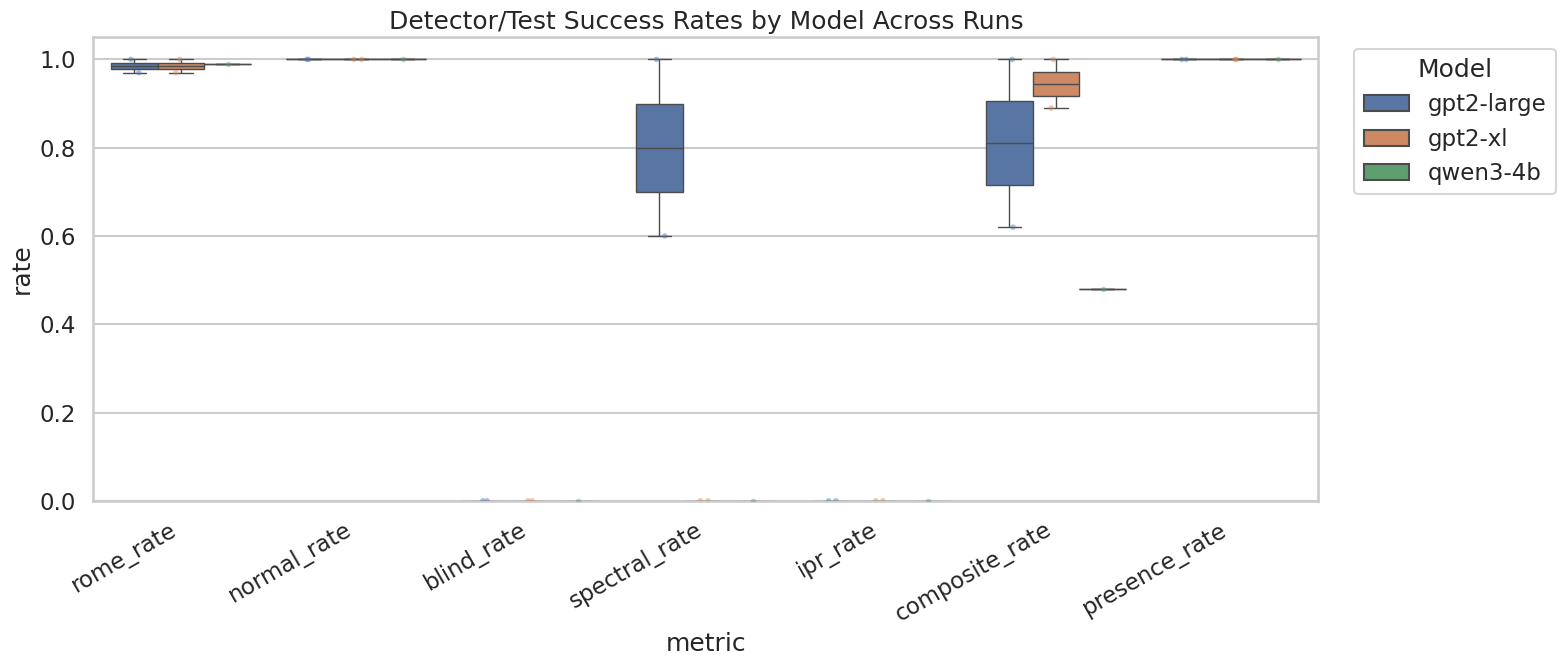

In [ ]:
rate_cols = ['rome_rate', 'normal_rate', 'blind_rate', 'spectral_rate', 'ipr_rate', 'composite_rate', 'presence_rate']
rate_long = runs_df.melt(
    id_vars=['model', 'file', 'run_time'],
    value_vars=rate_cols,
    var_name='metric',
    value_name='rate'
).dropna(subset=['rate'])

if rate_long.empty:
    print('No detector/test success rate metrics found across runs.')
else:
    plt.figure(figsize=(16, 7))
    sns.boxplot(data=rate_long, x='metric', y='rate', hue='model', showfliers=False)
    sns.stripplot(data=rate_long, x='metric', y='rate', hue='model', dodge=True, alpha=0.45, size=4)
    plt.title('Detector/Test Success Rates by Model Across Runs')
    plt.xticks(rotation=30, ha='right')
    handles, labels = plt.gca().get_legend_handles_labels()
    mid = len(labels) // 2
    plt.legend(handles[:mid], labels[:mid], title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

## Baseline spectral profile overlays (rome_hybrid_scores)

In [ ]:
baseline_rows = []
for row, payload in run_payloads:
    base_spec = get_baseline_spectral(payload)
    hybrid = base_spec.get('rome_hybrid_scores', {}) if isinstance(base_spec, dict) else {}
    if not hybrid and isinstance(base_spec, dict):
        hybrid = base_spec.get('hybrid_scores', {})

    for lk, val in hybrid.items():
        try:
            layer = int(lk)
            score = float(val)
        except Exception:
            continue
        baseline_rows.append({
            'model': row['model'],
            'file': row['file'],
            'layer': layer,
            'baseline_rome_hybrid_score': score,
            'target_layer': row['target_layer'],
        })

baseline_df = pd.DataFrame(
    baseline_rows,
    columns=['model', 'file', 'layer', 'baseline_rome_hybrid_score', 'target_layer']
)
print('Baseline spectral points:', len(baseline_df))
baseline_df.head()

Baseline spectral points: 204


,model,file,layer,baseline_rome_hybrid_score,target_layer
0,gpt2-large,rome_structural_gpt2-large_2026-03-23_14-31-56...,0,0.000000,12
1,gpt2-large,rome_structural_gpt2-large_2026-03-23_14-31-56...,1,0.000000,12
2,gpt2-large,rome_structural_gpt2-large_2026-03-23_14-31-56...,2,0.579036,12
3,gpt2-large,rome_structural_gpt2-large_2026-03-23_14-31-56...,3,0.743157,12
4,gpt2-large,rome_structural_gpt2-large_2026-03-23_14-31-56...,4,0.470868,12


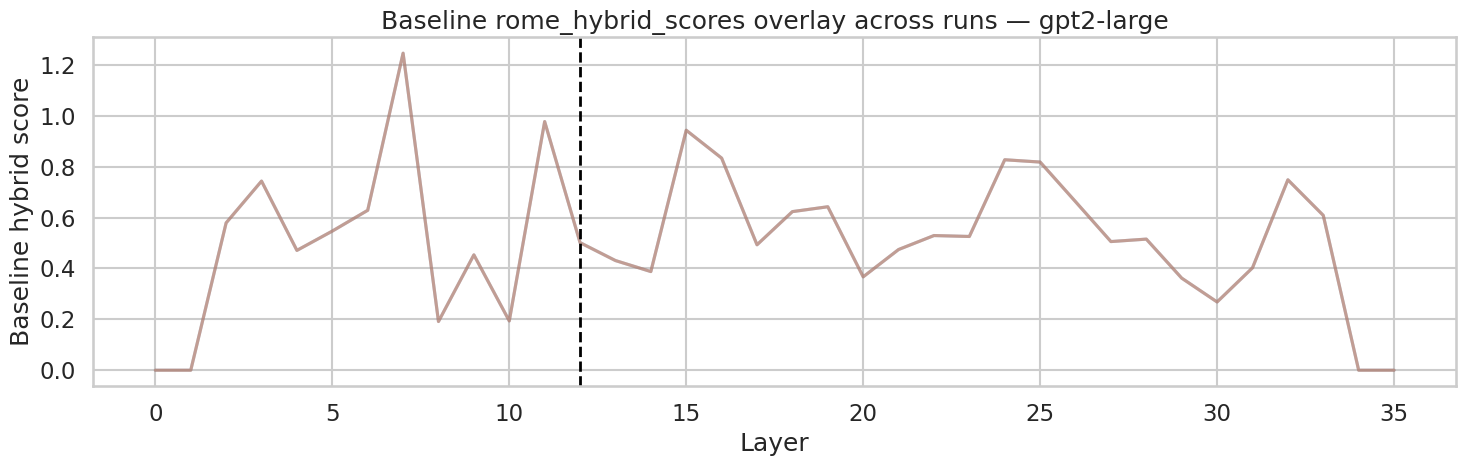

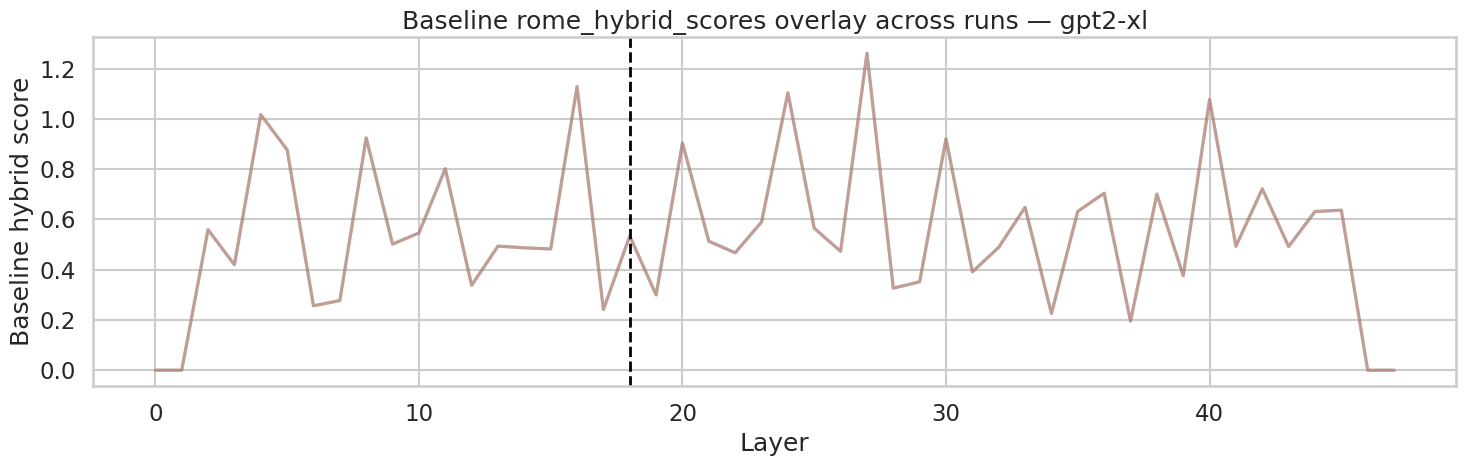

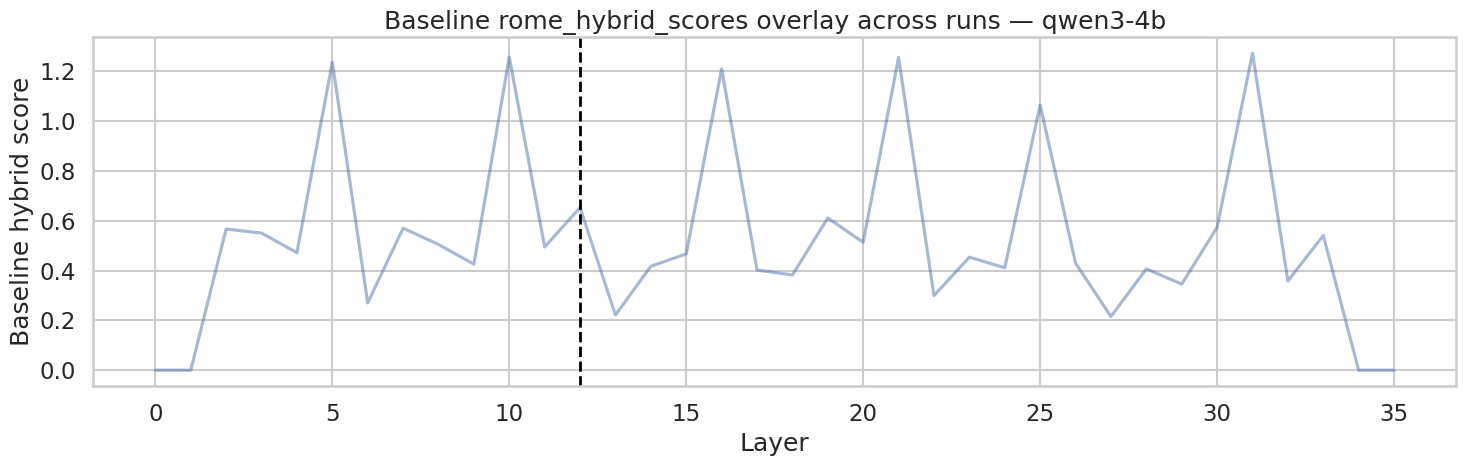

In [ ]:
if baseline_df.empty:
    print('No baseline spectral profiles found in loaded runs.')
else:
    models = sorted(baseline_df['model'].dropna().unique())
    for m in models:
        sub = baseline_df[baseline_df['model'] == m]
        if sub.empty:
            continue
        plt.figure(figsize=(15, 5))
        sns.lineplot(data=sub, x='layer', y='baseline_rome_hybrid_score', hue='file', legend=False, alpha=0.5)
        tl = sub['target_layer'].dropna()
        if not tl.empty:
            plt.axvline(tl.mode().iloc[0], color='black', linestyle='--', linewidth=2, label='target layer (mode)')
        plt.title(f'Baseline rome_hybrid_scores overlay across runs — {m}')
        plt.xlabel('Layer')
        plt.ylabel('Baseline hybrid score')
        plt.tight_layout()
        plt.show()

## Baseline blind isolation score overlays

In [ ]:
blind_base_rows = []
for row, payload in run_payloads:
    base_blind = get_baseline_blind(payload)
    iso = base_blind.get('isolation_scores', {}) if isinstance(base_blind, dict) else {}
    if not iso and isinstance(base_blind, dict):
        iso = base_blind.get('layer_scores', {})

    for lk, val in iso.items():
        try:
            blind_base_rows.append({
                'model': row['model'],
                'file': row['file'],
                'layer': int(lk),
                'baseline_isolation_score': float(val),
                'target_layer': row['target_layer'],
            })
        except Exception:
            continue

blind_base_df = pd.DataFrame(
    blind_base_rows,
    columns=['model', 'file', 'layer', 'baseline_isolation_score', 'target_layer']
)
print('Baseline blind points:', len(blind_base_df))

Baseline blind points: 204


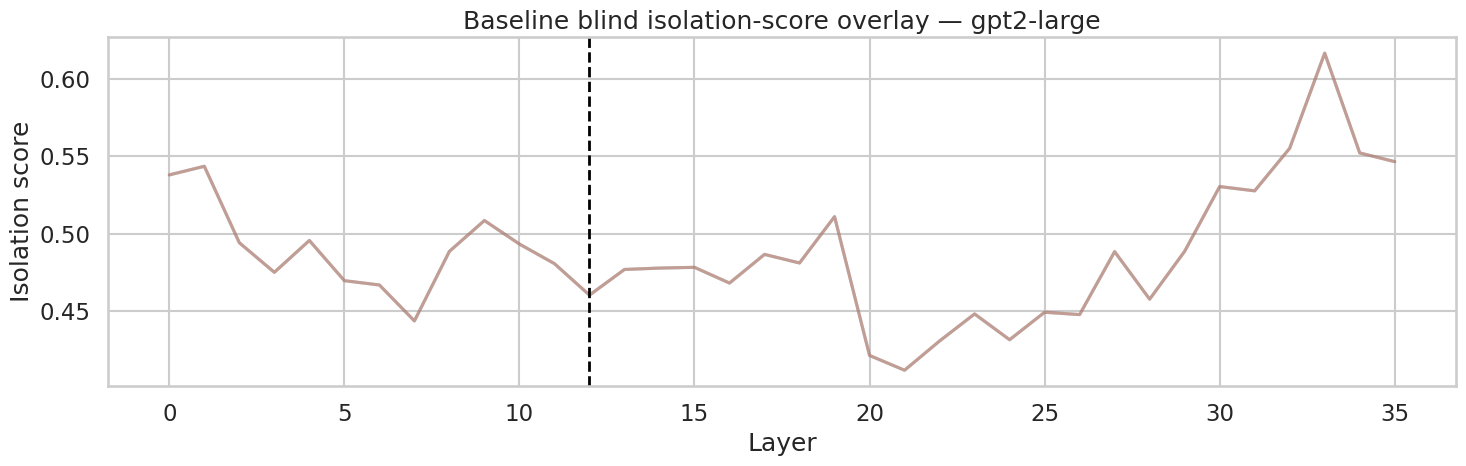

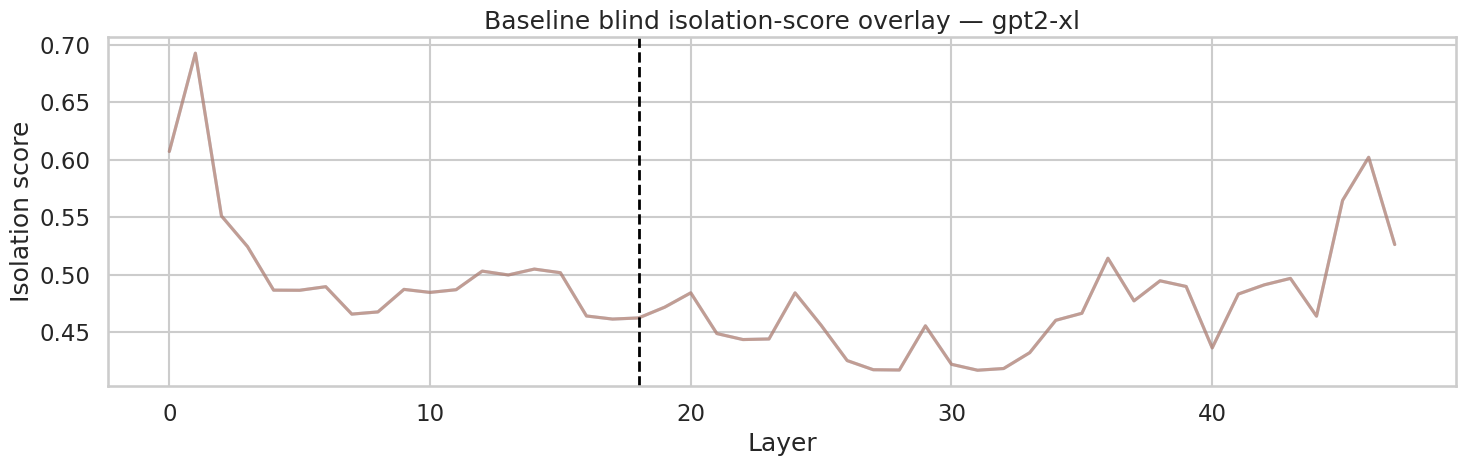

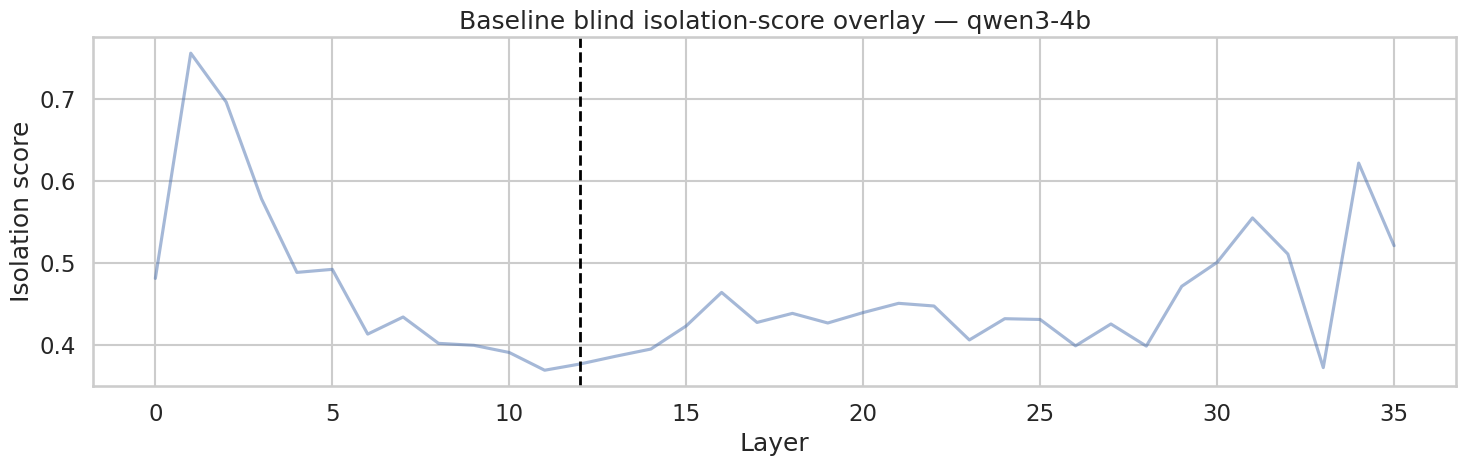

In [ ]:
if blind_base_df.empty:
    print('No baseline blind isolation profiles found in loaded runs.')
else:
    for m in sorted(blind_base_df['model'].dropna().unique()):
        sub = blind_base_df[blind_base_df['model'] == m]
        if sub.empty:
            continue
        plt.figure(figsize=(15, 5))
        sns.lineplot(data=sub, x='layer', y='baseline_isolation_score', hue='file', legend=False, alpha=0.5)
        tl = sub['target_layer'].dropna()
        if not tl.empty:
            plt.axvline(tl.mode().iloc[0], color='black', linestyle='--', linewidth=2)
        plt.title(f'Baseline blind isolation-score overlay — {m}')
        plt.xlabel('Layer')
        plt.ylabel('Isolation score')
        plt.tight_layout()
        plt.show()

## Baseline IPR profile overlays (proj global_ipr)

In [ ]:
ipr_base_rows = []
for row, payload in run_payloads:
    base_ipr = get_baseline_ipr(payload)
    proj = base_ipr.get('proj', {}) if isinstance(base_ipr, dict) else {}
    if not proj and isinstance(base_ipr, dict):
        proj = base_ipr

    for lk, vals in proj.items():
        if not isinstance(vals, dict):
            continue
        gipr = vals.get('global_ipr')
        if gipr is None:
            continue
        try:
            ipr_base_rows.append({
                'model': row['model'],
                'file': row['file'],
                'layer': int(lk),
                'baseline_global_ipr': float(gipr),
                'target_layer': row['target_layer'],
            })
        except Exception:
            continue

ipr_base_df = pd.DataFrame(
    ipr_base_rows,
    columns=['model', 'file', 'layer', 'baseline_global_ipr', 'target_layer']
)
print('Baseline IPR points:', len(ipr_base_df))

Baseline IPR points: 204


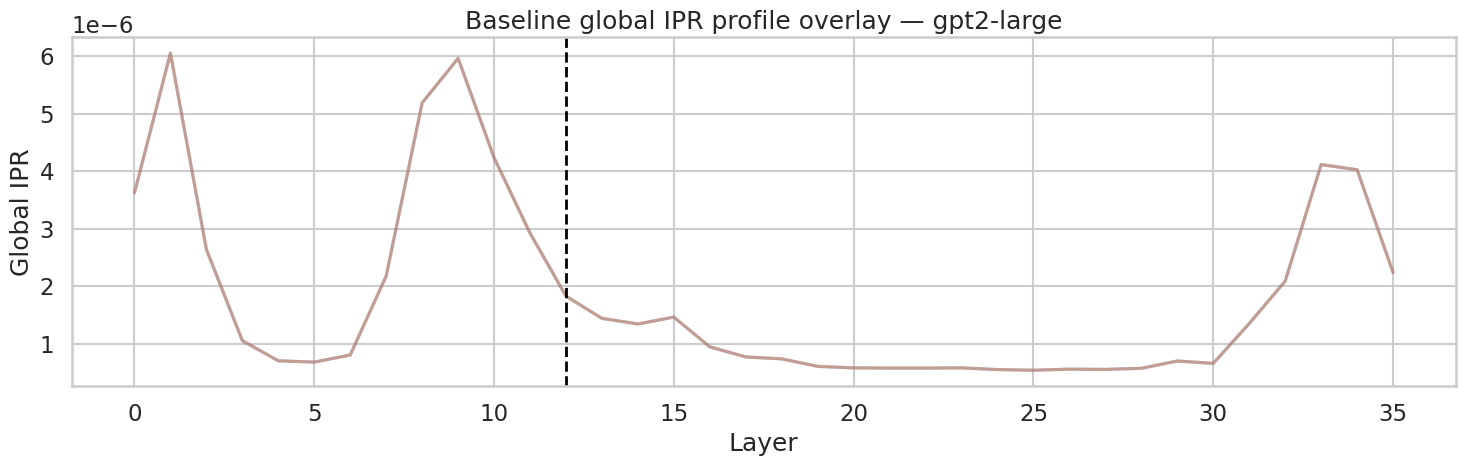

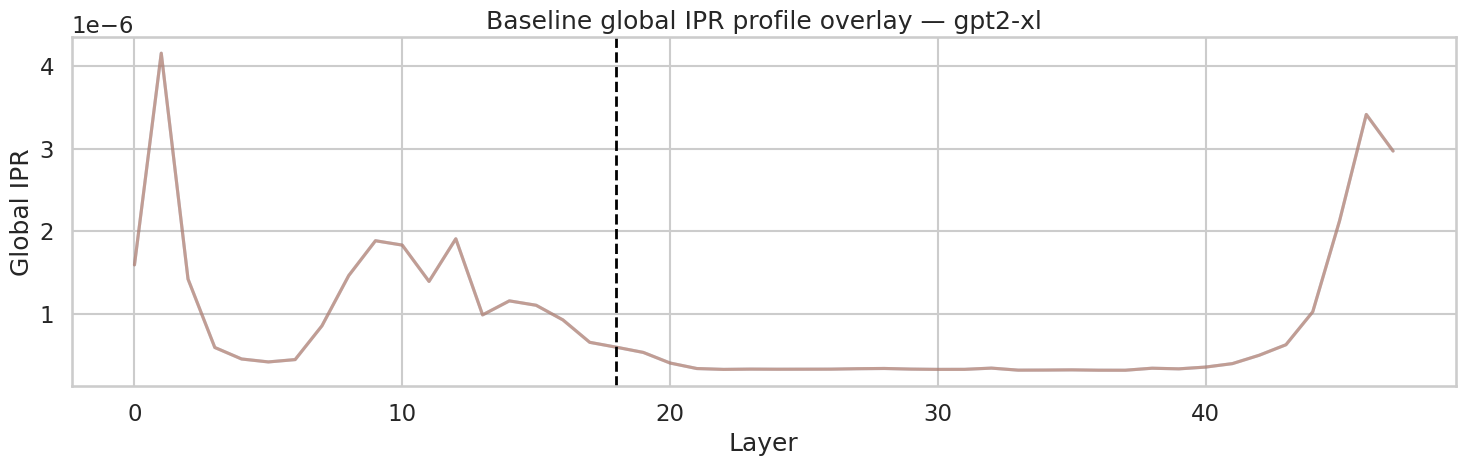

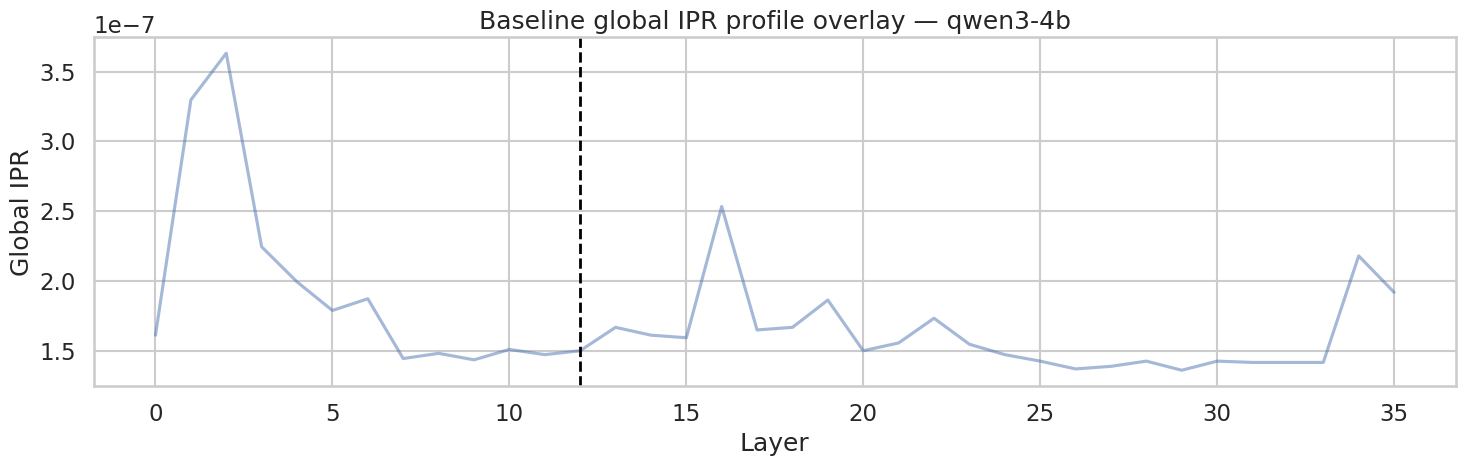

In [ ]:
if ipr_base_df.empty:
    print('No baseline IPR profiles found in loaded runs.')
else:
    for m in sorted(ipr_base_df['model'].dropna().unique()):
        sub = ipr_base_df[ipr_base_df['model'] == m]
        if sub.empty:
            continue
        plt.figure(figsize=(15, 5))
        sns.lineplot(data=sub, x='layer', y='baseline_global_ipr', hue='file', legend=False, alpha=0.5)
        tl = sub['target_layer'].dropna()
        if not tl.empty:
            plt.axvline(tl.mode().iloc[0], color='black', linestyle='--', linewidth=2)
        plt.title(f'Baseline global IPR profile overlay — {m}')
        plt.xlabel('Layer')
        plt.ylabel('Global IPR')
        plt.tight_layout()
        plt.show()

## Test-level absolute detection metrics (no deltas)

In [ ]:
test_rows = []
for row, payload in run_payloads:
    run_target = row.get('target_layer')

    base_spec = get_baseline_spectral(payload)
    base_hybrid_scores = {}
    if isinstance(base_spec, dict):
        base_hybrid_scores = base_spec.get('rome_hybrid_scores', {})
        if not base_hybrid_scores:
            base_hybrid_scores = base_spec.get('hybrid_scores', {})

    base_ipr = get_baseline_ipr(payload)
    base_proj = base_ipr.get('proj', {}) if isinstance(base_ipr, dict) else {}
    if not base_proj and isinstance(base_ipr, dict):
        base_proj = base_ipr

    for i, t in enumerate(get_tests(payload)):
        if bool(t.get('skipped')):
            continue

        target_layer = t.get('target_layer', run_target)
        try:
            target_layer = int(target_layer) if target_layer is not None else None
        except Exception:
            target_layer = run_target

        base_hybrid = get_layer_value(base_hybrid_scores, target_layer)
        base_ipr_target = np.nan
        if target_layer is not None:
            val = get_layer_value(base_proj, target_layer)
            if isinstance(val, dict):
                base_ipr_target = val.get('global_ipr', np.nan)

        sd = get_detection_block(t, 'spectral_detection', 'spectral')
        ipr = t.get('ipr', {}) if isinstance(t.get('ipr', {}), dict) else {}
        ipr_proj = ipr.get('proj', {}) if isinstance(ipr, dict) else {}

        hybrid_scores = sd.get('rome_hybrid_scores', {}) if isinstance(sd, dict) else {}
        if not hybrid_scores and isinstance(sd, dict):
            hybrid_scores = sd.get('hybrid_scores', {})
        mod_hybrid = get_layer_value(hybrid_scores, target_layer)

        mod_ipr_target = np.nan
        if target_layer is not None:
            iv = get_layer_value(ipr_proj, target_layer)
            if isinstance(iv, dict):
                mod_ipr_target = iv.get('global_ipr', np.nan)

        acc = t.get('accuracy', {}) if isinstance(t.get('accuracy', {}), dict) else {}
        comp = get_detection_block(t, 'composite_detection', 'composite')

        test_rows.append({
            'model': row['model'],
            'file': row['file'],
            'test_idx': i,
            'case_id': t.get('case_id'),
            'subject': t.get('subject'),
            'target_layer': target_layer,
            'baseline_hybrid_target': base_hybrid,
            'modified_hybrid_target': mod_hybrid,
            'baseline_global_ipr_target': base_ipr_target,
            'modified_global_ipr_target': mod_ipr_target,
            'rome_success': acc.get('rome_success'),
            'normal_correct': acc.get('normal_correct'),
            'blind_correct': acc.get('blind_correct'),
            'spectral_correct': acc.get('spectral_correct'),
            'ipr_correct': acc.get('ipr_correct'),
            'composite_correct': acc.get('composite_correct'),
            'presence_correct': acc.get('presence_correct'),
            'composite_method': comp.get('method_used') if isinstance(comp, dict) else None,
        })

tests_df = pd.DataFrame(
    test_rows,
    columns=[
        'model', 'file', 'test_idx', 'case_id', 'subject', 'target_layer',
        'baseline_hybrid_target', 'modified_hybrid_target',
        'baseline_global_ipr_target', 'modified_global_ipr_target',
        'rome_success', 'normal_correct', 'blind_correct', 'spectral_correct',
        'ipr_correct', 'composite_correct', 'presence_correct', 'composite_method'
    ]
)
print('Test records:', len(tests_df))
tests_df.head()

Test records: 302


,model,file,test_idx,case_id,subject,target_layer,baseline_hybrid_target,modified_hybrid_target,baseline_global_ipr_target,modified_global_ipr_target,rome_success,normal_correct,blind_correct,spectral_correct,ipr_correct,composite_correct,presence_correct,composite_method
0,gpt2-large,rome_structural_gpt2-large_2026-03-23_14-31-56...,0,0,Danielle Darrieux,12,0.501348,1.292905,0.000002,0.000002,True,True,False,True,False,True,True,spectral_hybrid
1,gpt2-large,rome_structural_gpt2-large_2026-03-24_01-20-36...,0,0,Danielle Darrieux,12,0.501348,1.296411,0.000002,0.000002,True,True,False,True,False,True,True,spectral_hybrid
2,gpt2-large,rome_structural_gpt2-large_2026-03-24_01-20-36...,1,1,Edwin of Northumbria,12,0.501348,1.268515,0.000002,0.000002,True,True,False,True,False,True,True,spectral_hybrid
3,gpt2-large,rome_structural_gpt2-large_2026-03-24_01-20-36...,2,2,Toko Yasuda,12,0.501348,1.296731,0.000002,0.000002,True,True,False,True,False,True,True,spectral_hybrid
4,gpt2-large,rome_structural_gpt2-large_2026-03-24_01-20-36...,3,3,Autonomous University of Madrid,12,0.501348,1.204799,0.000002,0.000002,True,True,False,False,False,False,True,spectral_hybrid


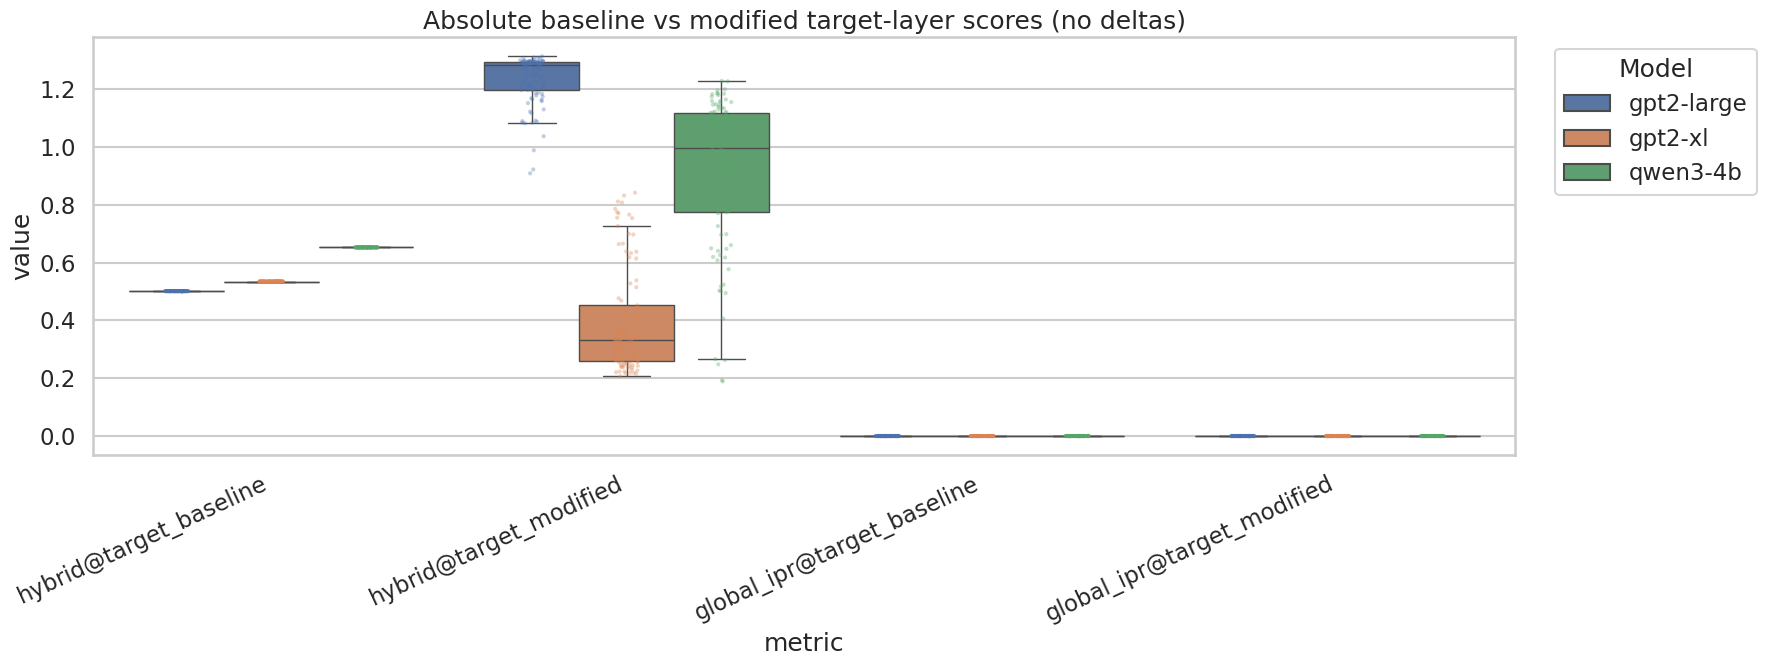

In [ ]:
if tests_df.empty:
    print('No test-level records available for absolute baseline/modified plots.')
else:
    abs_long = pd.concat([
        tests_df[['model', 'file', 'test_idx', 'target_layer', 'baseline_hybrid_target']]
        .rename(columns={'baseline_hybrid_target': 'value'})
        .assign(metric='hybrid@target_baseline'),

        tests_df[['model', 'file', 'test_idx', 'target_layer', 'modified_hybrid_target']]
        .rename(columns={'modified_hybrid_target': 'value'})
        .assign(metric='hybrid@target_modified'),

        tests_df[['model', 'file', 'test_idx', 'target_layer', 'baseline_global_ipr_target']]
        .rename(columns={'baseline_global_ipr_target': 'value'})
        .assign(metric='global_ipr@target_baseline'),

        tests_df[['model', 'file', 'test_idx', 'target_layer', 'modified_global_ipr_target']]
        .rename(columns={'modified_global_ipr_target': 'value'})
        .assign(metric='global_ipr@target_modified'),
    ], ignore_index=True)
    abs_long = abs_long.dropna(subset=['value'])

    if abs_long.empty:
        print('No non-null target-layer absolute values found in test records.')
    else:
        plt.figure(figsize=(18, 7))
        sns.boxplot(data=abs_long, x='metric', y='value', hue='model', showfliers=False)
        sns.stripplot(data=abs_long, x='metric', y='value', hue='model', dodge=True, alpha=0.35, size=3)
        plt.title('Absolute baseline vs modified target-layer scores (no deltas)')
        plt.xticks(rotation=25, ha='right')
        handles, labels = plt.gca().get_legend_handles_labels()
        mid = len(labels) // 2
        plt.legend(handles[:mid], labels[:mid], title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

## Detector hit-rate by model (test-level)

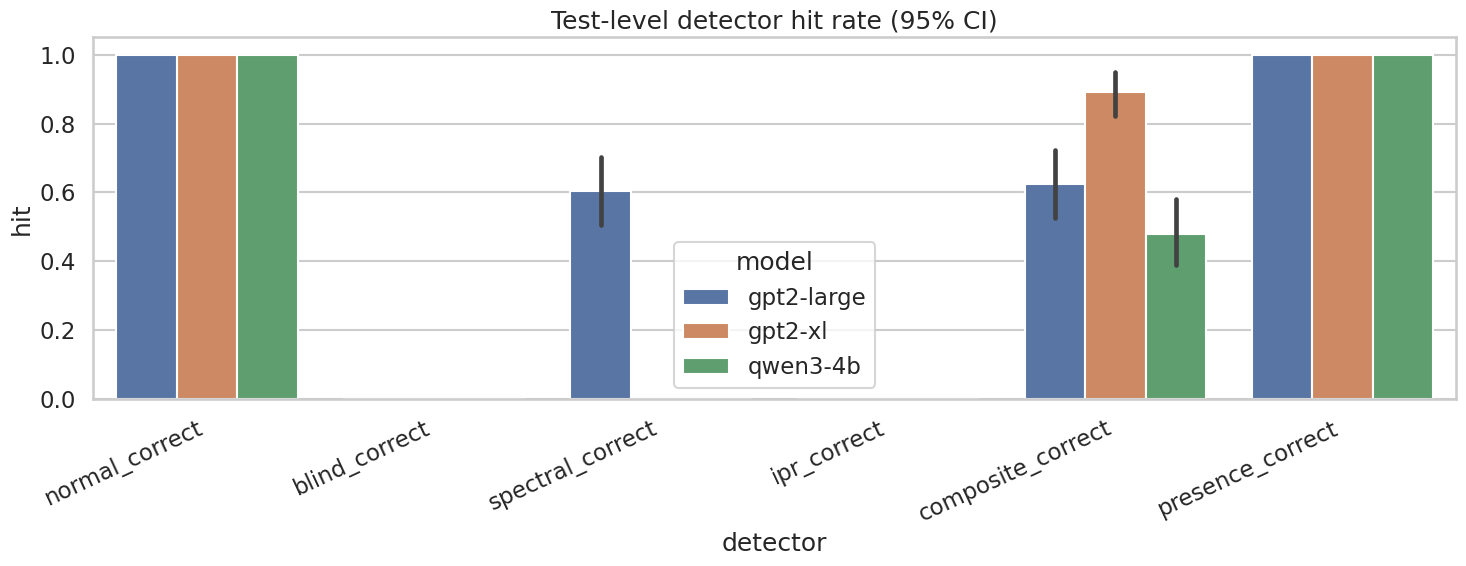

In [ ]:
if tests_df.empty:
    print('No test-level records available for detector hit-rate chart.')
else:
    hit_cols = ['normal_correct', 'blind_correct', 'spectral_correct', 'ipr_correct', 'composite_correct', 'presence_correct']
    hit_long = tests_df.melt(id_vars=['model', 'file'], value_vars=hit_cols, var_name='detector', value_name='hit')
    hit_long = hit_long.dropna(subset=['hit'])

    if hit_long.empty:
        print('No detector hit flags found in test records.')
    else:
        hit_long['hit'] = hit_long['hit'].astype(float)

        plt.figure(figsize=(15, 6))
        sns.barplot(data=hit_long, x='detector', y='hit', hue='model', errorbar=('ci', 95))
        plt.title('Test-level detector hit rate (95% CI)')
        plt.ylim(0, 1.05)
        plt.xticks(rotation=25, ha='right')
        plt.tight_layout()
        plt.show()

## Composite method usage by model

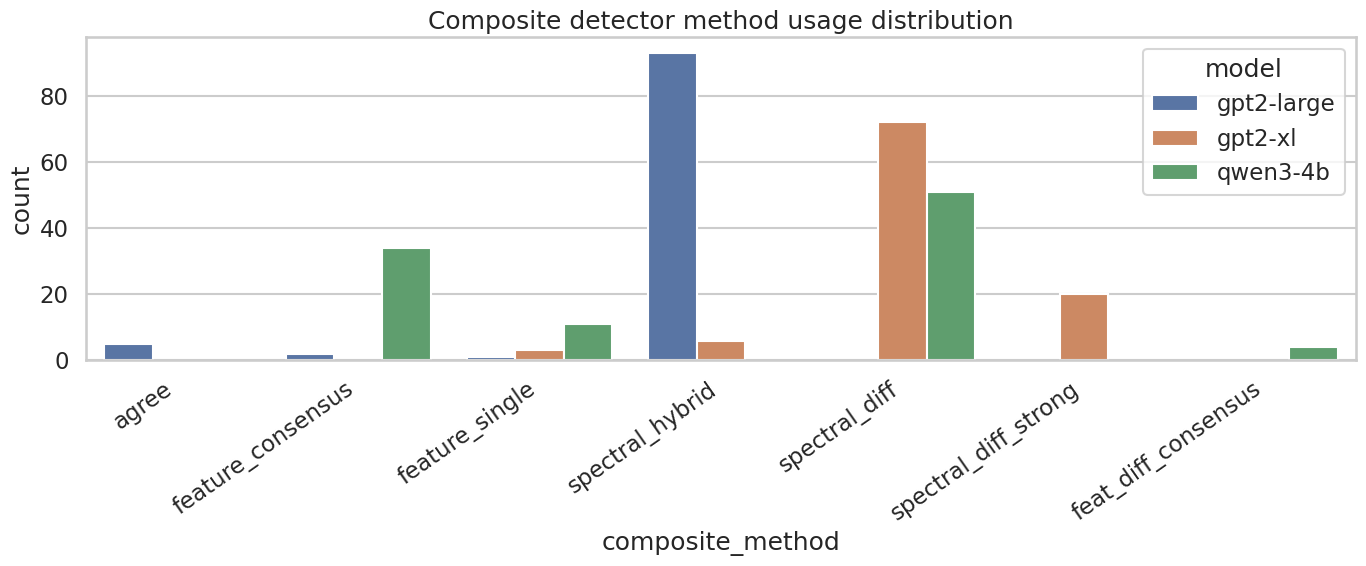

In [ ]:
if tests_df.empty or 'composite_method' not in tests_df.columns:
    print('No test-level composite method data found.')
else:
    method_df = tests_df.dropna(subset=['composite_method']).copy()
    if not method_df.empty:
        tmp = method_df.groupby(['model', 'composite_method']).size().reset_index(name='count')
        plt.figure(figsize=(14, 6))
        sns.barplot(data=tmp, x='composite_method', y='count', hue='model')
        plt.title('Composite detector method usage distribution')
        plt.xticks(rotation=35, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print('No composite method data found.')

## Run chronology: rates over time

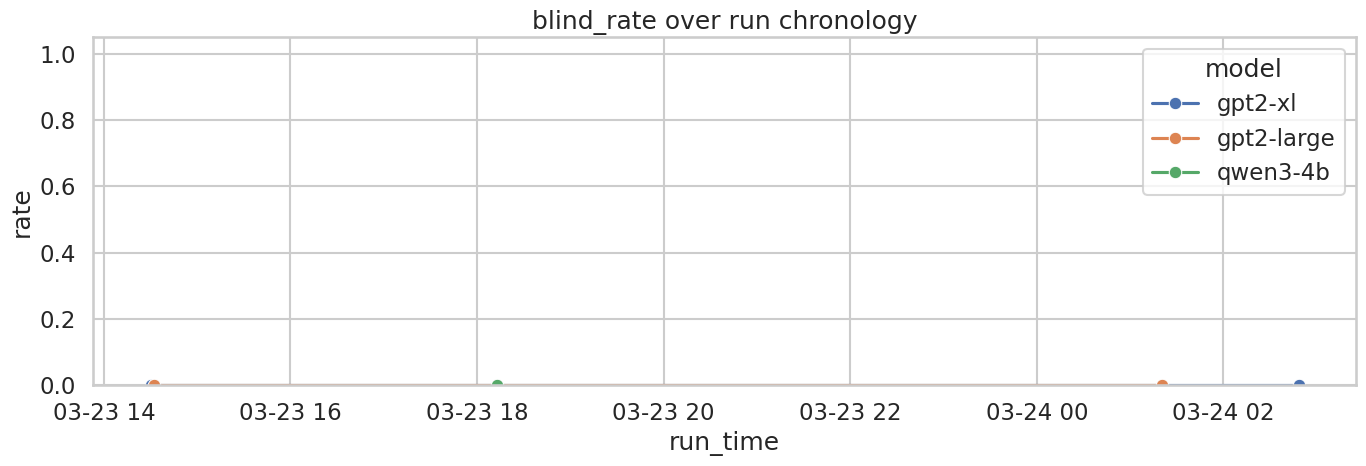

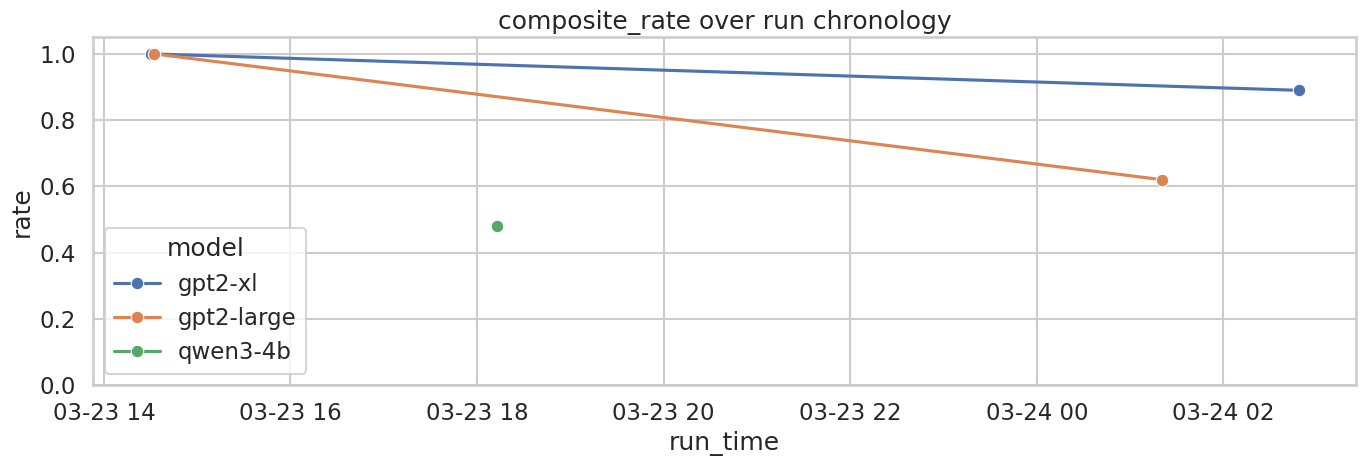

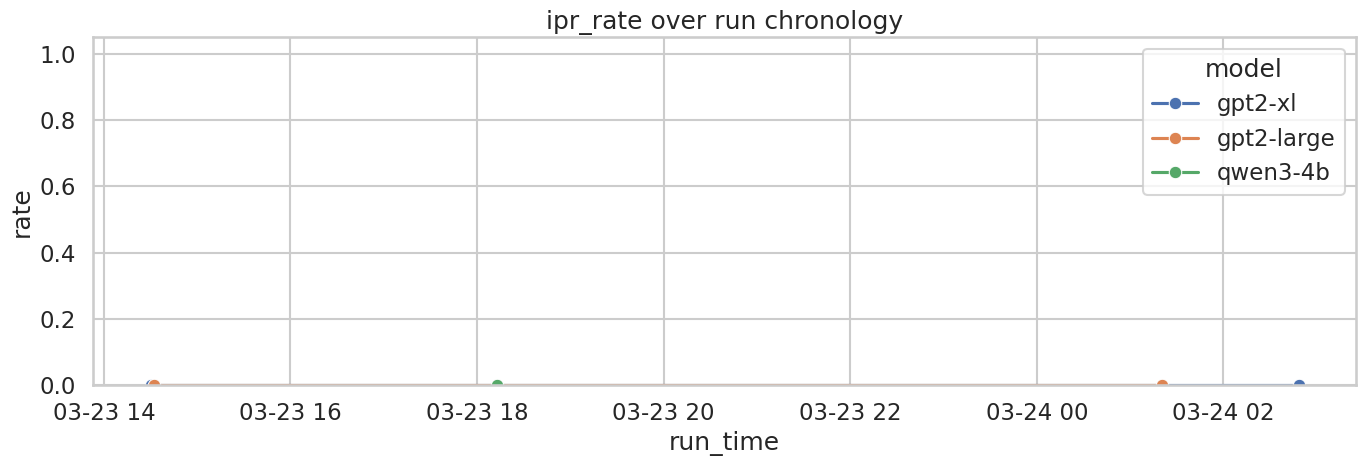

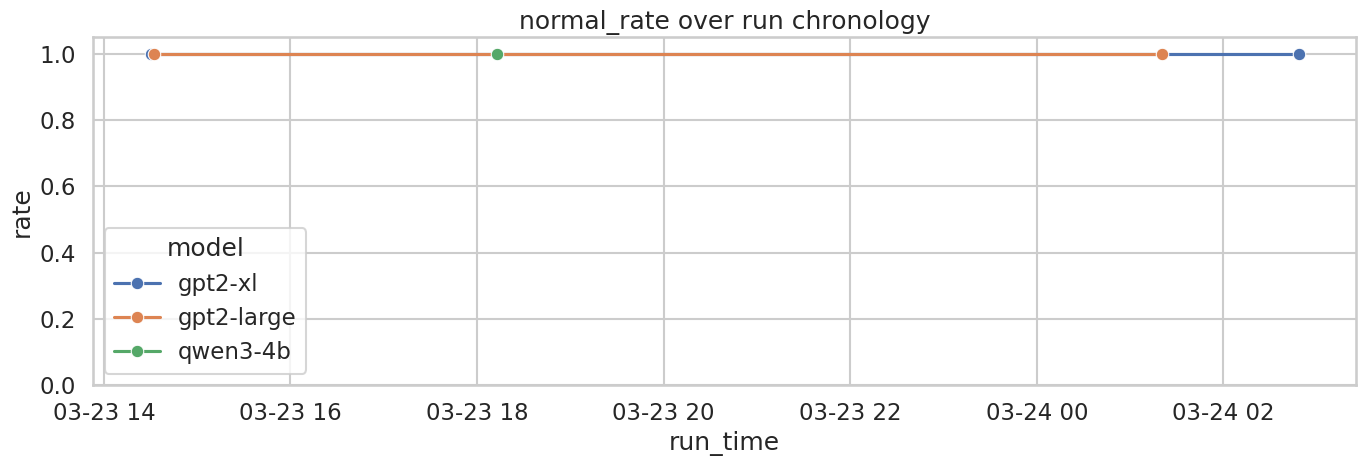

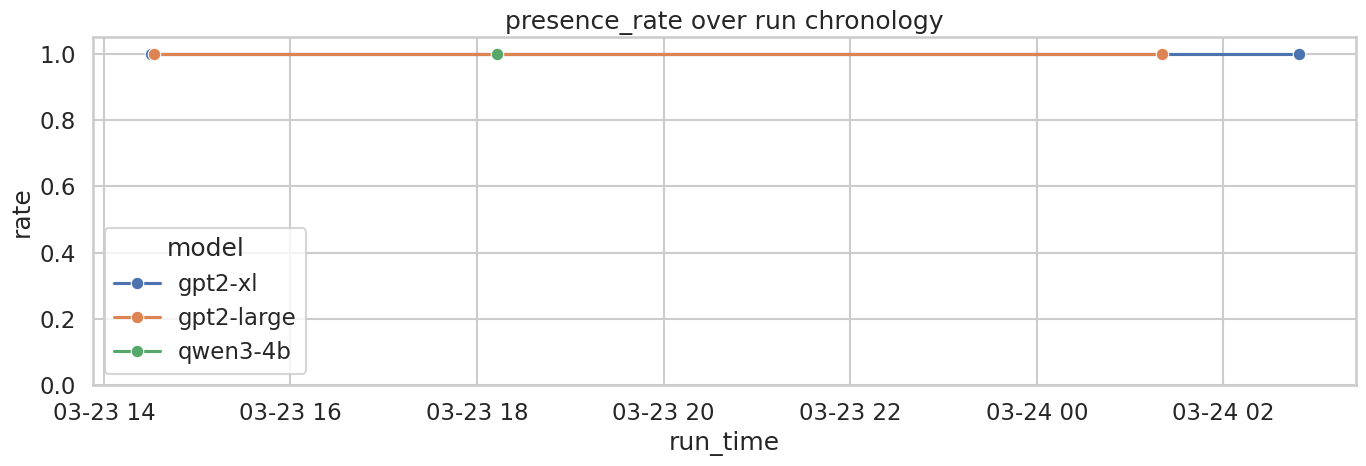

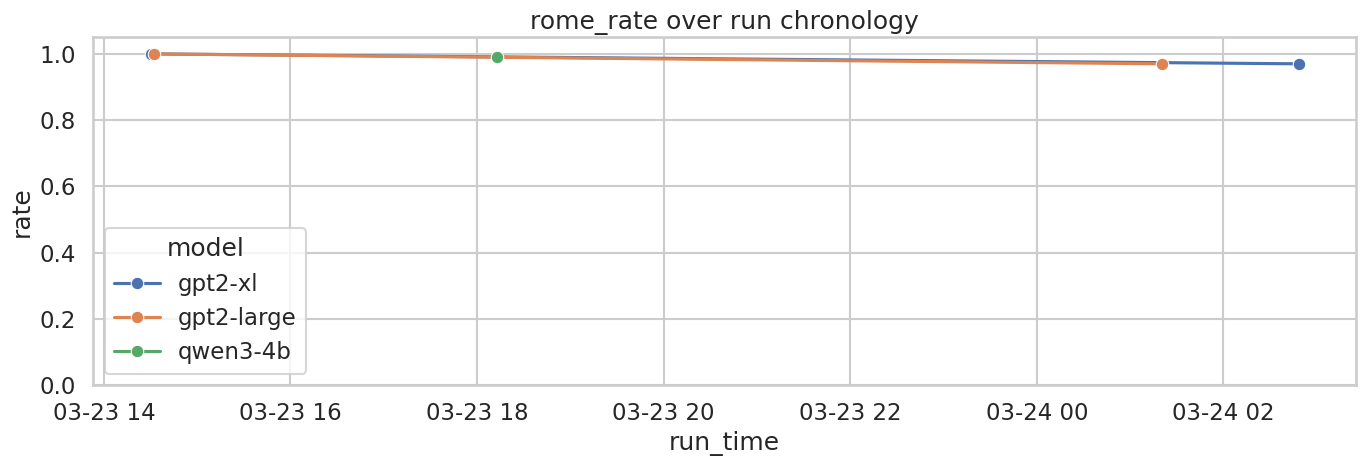

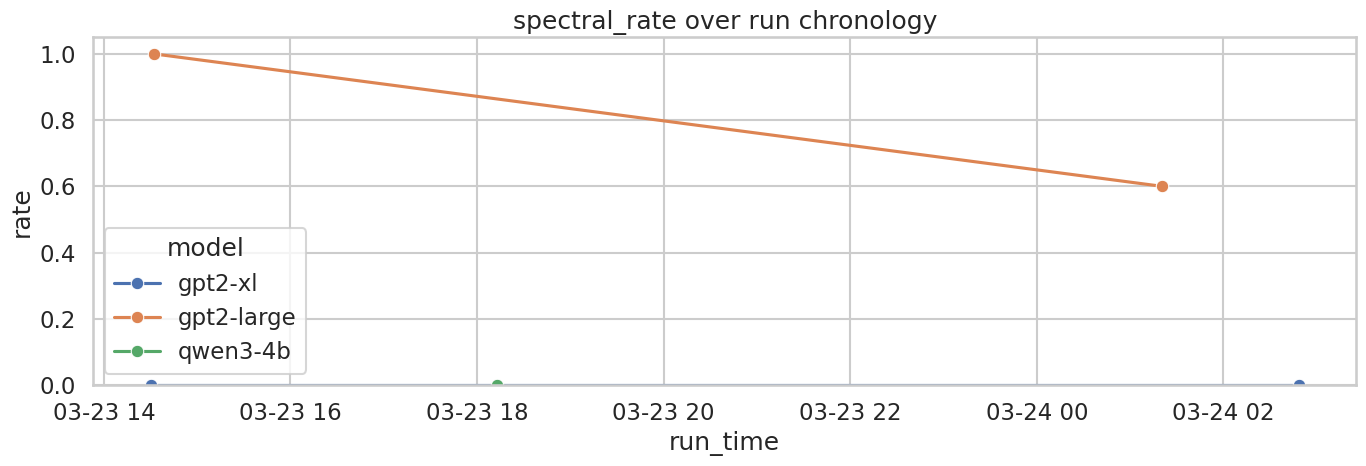

In [ ]:
chron = runs_df.dropna(subset=['run_time']).sort_values('run_time').copy()
chron_long = chron.melt(
    id_vars=['model','run_time','file'],
    value_vars=['rome_rate','normal_rate','blind_rate','spectral_rate','ipr_rate','composite_rate','presence_rate'],
    var_name='metric', value_name='rate'
).dropna(subset=['rate'])

for metric in sorted(chron_long['metric'].unique()):
    sub = chron_long[chron_long['metric'] == metric]
    plt.figure(figsize=(14,5))
    sns.lineplot(data=sub, x='run_time', y='rate', hue='model', marker='o')
    plt.title(f'{metric} over run chronology')
    plt.ylim(0,1.05)
    plt.tight_layout()
    plt.show()


## Failed / partial runs diagnostics

In [ ]:
failed = runs_df[runs_df['error'].notna()].copy()
if failed.empty:
    print('No failed runs found.')
else:
    display(failed[['model','file','run_time','error']])


,model,file,run_time,error
5,qwen3-8b,rome_structural_qwen3-8b_2026-03-23_15-07-20.json,2026-03-23 15:07:20.081668,Missing second moment stats for model=Qwen/Qwe...


## Model coverage check requested for this study

In [ ]:
requested_models = ['gpt2-xl', 'gpt2-large', 'qwen3-4b', 'qwen3-8b', 'mistral-7b-v0.1']
coverage_rows = []
for m in requested_models:
    sub = runs_df[runs_df['model'].str.lower() == m.lower()]
    successful_runs = sub[sub['error'].isna() & (sub['n_tests_records'] > 0)]
    best_n_tests = successful_runs['n_tests_records'].max() if not successful_runs.empty else 0
    coverage_rows.append({
        'requested_model': m,
        'runs_found': len(sub),
        'successful_runs': len(successful_runs),
        'best_tests_in_single_run': int(best_n_tests) if pd.notna(best_n_tests) else 0,
        'status': 'covered' if len(successful_runs) > 0 else 'missing_or_failed_only',
    })
coverage_df = pd.DataFrame(coverage_rows)
coverage_df


,requested_model,runs_found,successful_runs,best_tests_in_single_run,status
0,gpt2-xl,2,2,100,covered
1,gpt2-large,2,2,100,covered
2,qwen3-4b,1,1,100,covered
3,qwen3-8b,1,0,0,missing_or_failed_only
4,mistral-7b-v0.1,0,0,0,missing_or_failed_only
